/home/mc06/Documents/CamCAN/code/camcan_meglongrest_specparamlme_2026/results
Data directory: /home/mc06/Documents/CamCAN/code/camcan_meglongrest_specparamlme_2026/data
  Processing phase: p2
  Processing phase: p5


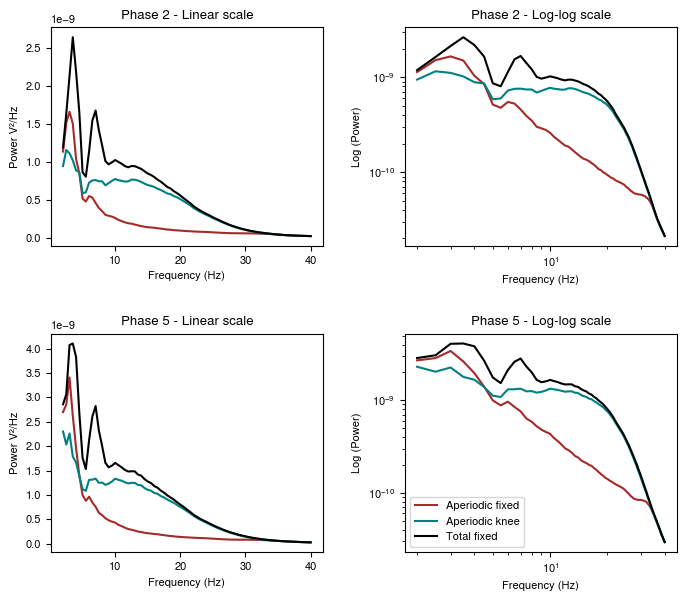

In [1]:
"""
Script to plot Supplementary Figure 6, with ECG total and aperiodic spectra with/without knee in both linear and log-log scales.
"""
import pandas as pd
import matplotlib.pyplot as plt
import os

print(os.getcwd())
datadir = os.path.abspath(os.path.join(os.path.dirname( os.getcwd() ), '.', 'data'))
print(f'Data directory: {datadir}')

pipver = 'stier'
task = 'rest'
phases = ['p2', 'p5']

phases_dict = {
    'p2': {'label': 'Phase 2', 'color': 'deepskyblue'},
    'p5': {'label': 'Phase 5', 'color': 'deeppink'}
}

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Nimbus Sans"]
plt.rcParams['font.size'] = 8

fig, axs = plt.subplots(2, 2, figsize=(7.2, 7), gridspec_kw={'wspace': 0.3, 'hspace': 0.4, 'left':0.10, 'right':0.97, 'top':0.90, 'bottom':0.15}) 

plot_spectra = [None, None, None] # to store spectra for each phase and type (aperiodic fixed, aperiodic knee, total fixed)
for p, phase in enumerate(phases):
    print(f'  Processing phase: {phase}')

    # Load source data created with supp_figure03_source_data.ipynb script
    source_df = pd.read_csv(os.path.join(datadir, f'supp_figure06_{phase}_source_data.csv'))
    plot_freqs = source_df['freqs'].values
    plot_spectra[0] = source_df['aperiodic_fixed'].values
    plot_spectra[1] = source_df['aperiodic_knee'].values
    plot_spectra[2] = source_df['total_fixed'].values
    chan_units = source_df['units'].values[0]

    # Plot spectra with normal units
    ax = axs[p, 0]
    ax.plot(plot_freqs, plot_spectra[0], label='Aperiodic fixed', color='brown')
    ax.plot(plot_freqs, plot_spectra[1], label='Aperiodic knee', color='teal')
    ax.plot(plot_freqs, plot_spectra[2], label='Total fixed', color='black')
    ax.set_title(f'{phases_dict[phase]["label"]} - Linear scale')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel(f'Power {chan_units}')

    # Plot spectra with log-log scale
    ax = axs[p, 1]
    ax.loglog(plot_freqs, plot_spectra[0], label='Aperiodic fixed', color='brown', subs='all')
    ax.loglog(plot_freqs, plot_spectra[1], label='Aperiodic knee', color='teal', subs='all')
    ax.loglog(plot_freqs, plot_spectra[2], label='Total fixed', color='black', subs='all')
    ax.set_title(f'{phases_dict[phase]["label"]} - Log-log scale')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel(f'Log (Power)')

plt.legend()

plt.savefig(f'Supp_Figure06.png', dpi=300)